# Recipe Clustering V8 – Analysis Notebook

Clusters strawberry-aroma recipes (Versuchsdaten_3_1.csv) using **4 FAISS models** with different combined ingredient weight strategies.

### What's new vs V7
| Aspect | V7 | V8 |
|--------|----|----|
| **Excluded terms** | None | `fruity` removed from vocabulary |

All other aspects (data, preprocessing, 4 models, Odour Type-only columns) are identical to V7.

---

### Models
| # | Model name | Columns | Threshold |
|---|-----------|---------|-----------|
| 1 | as is × gewichtete Subfamilien | OT 1–3 (pos-weighted, n_cols=4) | No |
| 2 | as is × Grandfamilien | OT 1 only | No |
| 3 | as is/Threshold × gewichtete Subfamilien | OT 1–3 (pos-weighted, n_cols=4) | Yes |
| 4 | as is/Threshold × Grandfamilien | OT 1 only | Yes |

### Positional weights (Subfamilies, n_cols=4)
| Column | Position | Weight |
|--------|----------|--------|
| Odour Type 1 | 1 | 1.00 |
| Odour Type 2 | 2 | 0.75 |
| Odour Type 3 | 3 | 0.50 |


## Setup

In [1]:
# Uncomment to install if needed
# !pip install pandas numpy scikit-learn faiss-cpu matplotlib


In [2]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

try:
    import faiss
    FAISS_AVAILABLE = True
    print("FAISS available")
except ImportError:
    FAISS_AVAILABLE = False
    print("FAISS not available – cannot run this notebook")

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
print("Libraries loaded successfully")


FAISS available
Libraries loaded successfully


In [3]:
# V8: terms excluded from vocabulary before vector extraction
EXCLUDE_TERMS = ['fruity']
exclude_set   = {t.lower().strip() for t in EXCLUDE_TERMS}
print(f"Excluded terms: {sorted(exclude_set)}")


Excluded terms: ['fruity']


---
## 1. Load Data & Preprocessing

### 1a. Load raw Versuchsdaten_3_1.csv


In [4]:
DATA_PATH   = '../data/gold/Versuchsdaten_3_1.csv'
IGNORE_PATH = '../data/gold/ignone_substances.csv'
CAS_PATH    = '../data/gold/CAS Nummern.csv'
OUTPUT_DIR  = '../outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df_raw = pd.read_csv(DATA_PATH)
ign    = pd.read_csv(IGNORE_PATH)
cas    = pd.read_csv(CAS_PATH, header=13)

print(f"Versuchsdaten_3_1: {df_raw.shape[0]} rows, {df_raw['Rez.-Nr.'].nunique()} recipes")
print(f"Ignore substances: {len(ign)} entries")
print(f"CAS lookup table : {len(cas)} entries, columns: {cas.columns.tolist()}")


Versuchsdaten_3_1: 658 rows, 24 recipes
Ignore substances: 9 entries
CAS lookup table : 1341 entries, columns: ['Stamm-Nr.', 'Stammbezeichnung', 'Ident.', 'Vers.', 'Int. Id.', 'Partner', 'CAS-Nr.: - Hinweis 1', 'Unnamed: 7']


In [5]:
df_raw.head(3)

,Stamm-Nr.,Rez.-Nr.,R-Nummer,ERP-Nr.,Name,Totalmenge,CAS-Nr.: - Hinweis 1,Sensorik_1,Sensorik_2,Sensorik_3,Sensorik_4,Odour Type 1 FlavourWheel,Odour Type 2 Flavour Wheel,Odour Type 3 Flavour Wheel,Threshold ppm (Datenbank),Unnamed: 15,Unnamed: 16,Unnamed: 17
0,29201891,187.796P,R01643,60030184,gamma-Dodecalacton Halal Kosher,0.014596,2305-05-7,Fatty,peach,metallic,fruity,warm,balsamic,fruity,"0,666666667",NaN,NaN,NaN
1,RE00429_A02,185.028,R01937,60030396,"gamma-Dodecalacton, natürlich Halal",0.000012,2305-05-7,Fatty,peach,metallic,fruity,warm,balsamic,fruity,"0,666666667",NaN,NaN,Fehlt:
2,29201231,185.507P,R01937,60030396,"gamma-Dodecalacton, natürlich Halal",0.000001,2305-05-7,Fatty,peach,metallic,fruity,warm,balsamic,fruity,"0,666666667",NaN,NaN,185.569


In [6]:
ign

,Ident,Name,Unnamed: 2
0,R01776,Propylenglycol Kosher Halal,NaN
1,R01356,Milchsäure 80%ig (als Aromastoff) Halal Kosher,NaN
2,R01420,MCT Öl palmölbasiert,NaN
3,R01655,Glycerin (palmölfrei) Halal,NaN
4,R01935,Triacetin Kosher Halal,NaN
5,R02119,Ethanol (unversteuert) IP Kosher,NaN
6,R03370,Wasser,NaN
7,R04390,"Sonnenblumen-Öl Raffinat, Ölsäurereich V Halal",NaN
8,R07705,"Invertzuckersirup 72,7/67 (als Trägerstoff)",NaN


### 1b. Identify ignored substances via CAS number lookup

Matching chain:
```
ignone_substances.csv  →  (Ident)  →  CAS Nummern.csv  →  (CAS-Nr.)  →  Versuchsdaten_3_1.csv
```
1. Join `ignone_substances` (Ident) with `CAS Nummern` (Ident.) to get each substance's CAS number
2. Zero out `Totalmenge` for any row whose `CAS-Nr.: - Hinweis 1` matches


In [7]:
# Step 1: join ignore list with CAS lookup
ign_cas = ign[['Ident']].merge(
    cas[['Ident.', 'CAS-Nr.: - Hinweis 1']].rename(columns={'Ident.': 'Ident'}),
    on='Ident', how='left'
)
print("Ignore list with resolved CAS numbers:")
print(ign_cas.to_string(index=False))

# Step 2: extract valid CAS numbers
cas_to_ignore = set(ign_cas['CAS-Nr.: - Hinweis 1'].dropna().astype(str).str.strip())
print(f"\nCAS numbers resolved : {len(cas_to_ignore)}")
print(f"Entries without CAS  : {ign_cas['CAS-Nr.: - Hinweis 1'].isna().sum()}")

# Step 3: zero out Totalmenge where CAS matches
df = df_raw.copy()
df['_cas'] = df['CAS-Nr.: - Hinweis 1'].astype(str).str.strip()
mask_ignored = df['_cas'].isin(cas_to_ignore)
n_zeroed = mask_ignored.sum()
df.loc[mask_ignored, 'Totalmenge'] = 0.0
df.drop(columns='_cas', inplace=True)

print(f"\nIngredient rows zeroed: {n_zeroed}")
zeroed = df_raw.loc[mask_ignored, ['Name', 'CAS-Nr.: - Hinweis 1']].drop_duplicates()
print("Substances zeroed (unique):")
print(zeroed.to_string(index=False))


Ignore list with resolved CAS numbers:
 Ident CAS-Nr.: - Hinweis 1
R01776              57-55-6
R01356              79-33-4
R01420           73398-61-5
R01655              56-81-5
R01935             102-76-1
R02119              64-17-5
R03370                  NaN
R04390            8001-21-6
R07705                  NaN

CAS numbers resolved : 7
Entries without CAS  : 2

Ingredient rows zeroed: 38
Substances zeroed (unique):
                                          Name CAS-Nr.: - Hinweis 1
                        Triacetin Kosher Halal             102-76-1
                   Propylenglycol Kosher Halal              57-55-6
              Ethanol (unversteuert) IP Kosher              64-17-5
Milchsäure 80%ig (als Aromastoff) Halal Kosher              79-33-4


### 1c. Re-normalise Totalmenge to aliquots (per recipe, sum = 1)

In [8]:
per_recipe_total = df.groupby('Rez.-Nr.')['Totalmenge'].transform('sum')
df['Totalmenge'] = np.where(per_recipe_total > 0,
                            df['Totalmenge'] / per_recipe_total,
                            df['Totalmenge'])

sums = df.groupby('Rez.-Nr.')['Totalmenge'].sum()
assert sums.round(6).eq(1.0).all(), "Not all recipes sum to 1!"

active_rows = (df['Totalmenge'] > 0).sum()
print(f"All recipe sums = 1.0  ✓")
print(f"Active ingredient rows: {active_rows} / {len(df)}")
print("Active ingredients per recipe (range):",
      df[df['Totalmenge']>0].groupby('Rez.-Nr.').size().agg(['min','mean','max']).to_dict())


All recipe sums = 1.0  ✓
Active ingredient rows: 620 / 658
Active ingredients per recipe (range): {'min': 14.0, 'mean': 25.833333333333332, 'max': 49.0}


### 1d. Preprocessing effect visualisation

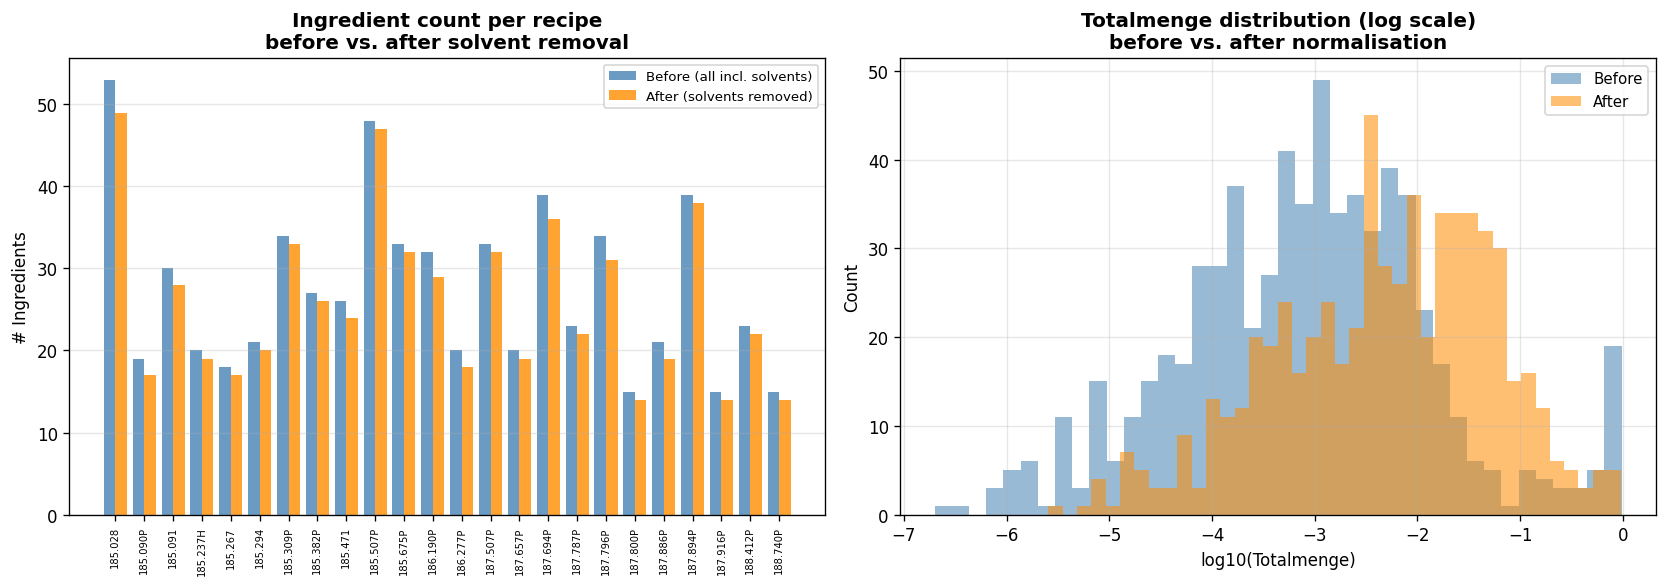

Saved → v7_preprocessing.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_before = df_raw.groupby('Rez.-Nr.').size()
n_after  = df[df['Totalmenge'] > 0].groupby('Rez.-Nr.').size()

ax = axes[0]
x = np.arange(len(n_before))
ax.bar(x - 0.2, n_before.values, 0.4, label='Before (all incl. solvents)', color='steelblue', alpha=0.8)
ax.bar(x + 0.2, n_after.reindex(n_before.index).fillna(0).values, 0.4,
       label='After (solvents removed)', color='darkorange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(n_before.index, rotation=90, fontsize=6)
ax.set_ylabel('# Ingredients')
ax.set_title('Ingredient count per recipe\nbefore vs. after solvent removal', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, axis='y', alpha=0.3)

ax2 = axes[1]
tq_before = df_raw['Totalmenge'].values
tq_after  = df[df['Totalmenge']>0]['Totalmenge'].values
ax2.hist(np.log10(tq_before[tq_before>0]), bins=40, alpha=0.55, color='steelblue', label='Before')
ax2.hist(np.log10(tq_after),               bins=40, alpha=0.55, color='darkorange', label='After')
ax2.set_xlabel('log10(Totalmenge)')
ax2.set_ylabel('Count')
ax2.set_title('Totalmenge distribution (log scale)\nbefore vs. after normalisation', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/v8_preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → v7_preprocessing.png")


---
## 2. Feature Extraction

### Column constants & helper functions


In [10]:
OT1 = 'Odour Type 1 FlavourWheel'
OT2 = 'Odour Type 2 Flavour Wheel'
OT3 = 'Odour Type 3 Flavour Wheel'
THRESHOLD_COL = 'Threshold ppm (Datenbank)'


def pos_weight(position, n_cols):
    """Descending positional weight: pos 1 → 1.0, pos n_cols → 1/n_cols"""
    return (n_cols + 1 - position) / n_cols


def thresh_factor(threshold_ppm, fallback=1.0):
    """Odour potency: 1/threshold. NaN/non-positive → fallback."""
    try:
        raw = str(threshold_ppm).strip().replace(',', '.')
        t = float(raw)
        return 1.0 / t if (not np.isnan(t) and t > 0) else fallback
    except (TypeError, ValueError):
        return fallback


def norm_term(term):
    if pd.isna(term) or not isinstance(term, str):
        return None
    t = term.lower().strip().replace('"', '').replace("'", '').rstrip('.,;:')
    return t if len(t) >= 2 else None


print("Weight examples (Subfamilies, n_cols=4):",
      {f'OT{p}': round(pos_weight(p, 4), 3) for p in range(1, 4)})
print("Threshold factor examples (1/T):",
      {f'{t} ppm': round(thresh_factor(t), 4) for t in [0.1, 1, 10, 100]})


Weight examples (Subfamilies, n_cols=4): {'OT1': 1.0, 'OT2': 0.75, 'OT3': 0.5}
Threshold factor examples (1/T): {'0.1 ppm': 10.0, '1 ppm': 1.0, '10 ppm': 0.1, '100 ppm': 0.01}


---
## 3. Parametric Helper Functions


In [11]:
def build_vocabulary(df, feature_cols):
    """Build sorted vocabulary from the specified columns."""
    all_terms = set()
    for col in feature_cols:
        if col in df.columns:
            for t in df[col].dropna().map(norm_term):
                if t and t not in exclude_set:
                    all_terms.add(t)
    return sorted(all_terms)


# Preview
vocab_sub   = build_vocabulary(df, [OT1, OT2, OT3])
vocab_grand = build_vocabulary(df, [OT1])
print(f"Subfamilies vocab  ({len(vocab_sub):2d} terms): {vocab_sub}")
print(f"Grandfamilies vocab ({len(vocab_grand):2d} terms): {vocab_grand}")


Subfamilies vocab  (10 terms): ['balsamic', 'dairy', 'exotic', 'floral', 'fresh', 'green', 'odorless', 'unpleasant', 'warm', 'woody']
Grandfamilies vocab ( 8 terms): ['dairy', 'floral', 'fresh', 'green', 'odorless', 'unpleasant', 'warm', 'woody']


In [12]:
def build_recipe_vectors(df, recipes, feature_cols_weighted, use_threshold):
    """
    Build L2-normalised recipe vectors.

    Parameters
    ----------
    feature_cols_weighted : list of (column_name, weight) tuples
        Each column contributes `col_weight * ingr_base` to the term's dimension.
    use_threshold : bool
        If True, ingr_base = Totalmenge * (1/Threshold).
        If False, ingr_base = Totalmenge.
    """
    feature_cols = [col for col, _ in feature_cols_weighted]
    vocab = build_vocabulary(df, feature_cols)
    vocab_to_idx = {t: i for i, t in enumerate(vocab)}

    n_recipes = len(recipes)
    n_feat    = len(vocab)
    vectors   = np.zeros((n_recipes, n_feat), dtype=np.float64)

    for r_idx, recipe in enumerate(recipes):
        rows = df[df['Rez.-Nr.'] == recipe]
        for _, row in rows.iterrows():
            qty = float(row['Totalmenge'])
            if qty <= 0:
                continue
            t_fac     = thresh_factor(row[THRESHOLD_COL]) if use_threshold else 1.0
            ingr_base = qty * t_fac

            for col, col_weight in feature_cols_weighted:
                if col not in df.columns:
                    continue
                term = norm_term(row.get(col))
                if term and term not in exclude_set and term in vocab_to_idx:
                    vectors[r_idx, vocab_to_idx[term]] += col_weight * ingr_base

    return vocab, normalize(vectors)


print("build_recipe_vectors defined ✓")


build_recipe_vectors defined ✓


In [13]:
def run_faiss_clustering(recipe_vecs, k_range=(3, 12)):
    """Auto-select k via silhouette score, return best clustering."""
    if not FAISS_AVAILABLE:
        raise RuntimeError("FAISS not available")

    vectors_f32 = np.ascontiguousarray(recipe_vecs.astype('float32'))
    n_v, d = vectors_f32.shape

    scores = []
    best_k, best_score = k_range[0], -1
    best_labels, best_centroids = None, None

    for k in range(k_range[0], min(k_range[1] + 1, n_v)):
        km = faiss.Kmeans(d, k, niter=50, verbose=False, seed=42)
        km.train(vectors_f32)
        _, lbl = km.index.search(vectors_f32, 1)
        lbl = lbl.flatten()
        if len(set(lbl)) > 1:
            s = silhouette_score(vectors_f32, lbl)
            scores.append((k, s))
            if s > best_score:
                best_score    = s
                best_k        = k
                best_labels   = lbl.copy()
                best_centroids = km.centroids.copy()

    return best_labels, best_k, best_score, best_centroids, scores


print("run_faiss_clustering defined ✓")


run_faiss_clustering defined ✓


In [14]:
def generate_cluster_names(cluster_labels, recipe_vecs, vocab, top_n=3):
    unique_labels = sorted(set(cluster_labels))
    global_cen    = recipe_vecs.mean(axis=0)
    centroids = {l: recipe_vecs[cluster_labels == l].mean(axis=0)
                 for l in unique_labels if l != -1}
    names = {}
    for label in unique_labels:
        if label == -1:
            names[label] = 'Outliers'
            continue
        cen     = centroids[label]
        dist    = cen - global_cen * 0.8
        top_idx = np.argsort(dist)[-6:][::-1]
        terms   = [vocab[i].capitalize()
                   for i in top_idx if dist[i] > 0 and cen[i] > 0.05][:top_n]
        if len(terms) < 2:
            terms = [vocab[i].capitalize()
                     for i in np.argsort(cen)[-top_n:][::-1]]
        names[label] = '-'.join(terms[:top_n])
    return names


def get_details(cluster_labels, cluster_names, recipe_vecs, vocab, recipes):
    details = {}
    for label in sorted(set(cluster_labels)):
        mask    = cluster_labels == label
        vecs    = recipe_vecs[mask]
        cen     = vecs.mean(axis=0)
        top_idx = np.argsort(cen)[-10:][::-1]
        details[label] = {
            'name'     : cluster_names.get(label, f'C{label}'),
            'recipes'  : [recipes[i] for i, m in enumerate(mask) if m],
            'centroid' : cen,
            'top_terms': [(vocab[i], float(cen[i])) for i in top_idx],
            'size'     : int(mask.sum()),
        }
    return details


def print_summary(details):
    for label in sorted(details):
        info = details[label]
        print(f"\n{'─'*48}")
        print(f"CLUSTER {label}: {info['name']}  ({info['size']} recipes)")
        print(f"{'─'*48}")
        for r in info['recipes']:
            print(f"  • {r}")
        print("  Top profile:")
        for term, w in info['top_terms'][:6]:
            print(f"    {term:20} {'█'*int(w*40)} ({w:.3f})")


print("Cluster naming and detail functions defined ✓")


Cluster naming and detail functions defined ✓


In [15]:
def visualize_clusters(cluster_labels, cluster_names, details,
                       recipe_vecs, vocab, recipes,
                       title, save_path=None, figsize=(16, 8)):
    data = recipe_vecs
    if data.shape[1] > 50:
        pca  = PCA(n_components=min(30, data.shape[0] - 1))
        data = pca.fit_transform(data)
    perp   = min(5, len(recipes) - 1)
    coords = TSNE(n_components=2, perplexity=perp, random_state=42,
                  max_iter=1000).fit_transform(data)

    unique_labels = sorted(set(cluster_labels))
    colors = plt.cm.Set2(np.linspace(0, 1, max(len(unique_labels), 8)))
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # t-SNE scatter
    ax1 = axes[0]
    for i, label in enumerate(unique_labels):
        mask = cluster_labels == label
        pts  = coords[mask]
        c    = 'gray' if label == -1 else colors[i % len(colors)]
        m    = 'x'    if label == -1 else 'o'
        ax1.scatter(pts[:, 0], pts[:, 1], c=[c], marker=m, s=160,
                    alpha=0.85 if label != -1 else 0.5,
                    label=cluster_names.get(label, f'C{label}'),
                    edgecolors='black', lw=0.5)
    for i, rec in enumerate(recipes):
        ax1.annotate(rec[:12], (coords[i, 0], coords[i, 1]),
                     fontsize=6.5, alpha=0.7, ha='center', va='bottom')
    ax1.set_xlabel('t-SNE Dim 1')
    ax1.set_ylabel('t-SNE Dim 2')
    ax1.set_title(f't-SNE Cluster Map\n{title}', fontsize=11, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=7.5, framealpha=0.9)
    ax1.grid(True, alpha=0.25)

    # Top terms bar chart
    ax2 = axes[1]
    y_pos, y_lab, bar_v, bar_c = [], [], [], []
    y = 0
    for label in unique_labels:
        if label == -1:
            continue
        clr = colors[label % len(colors)]
        for term, w in details[label]['top_terms'][:5]:
            y_pos.append(y); y_lab.append(term); bar_v.append(w); bar_c.append(clr)
            y += 1
        y += 0.6
    ax2.barh(y_pos, bar_v, color=bar_c, alpha=0.82)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(y_lab, fontsize=8)
    ax2.set_xlabel('Weighted Importance')
    ax2.set_title('Top Terms per Cluster', fontsize=11, fontweight='bold')
    ax2.invert_yaxis()
    ax2.grid(True, axis='x', alpha=0.25)
    # Cluster name annotations
    y = 0
    for label in unique_labels:
        if label == -1:
            continue
        info = details[label]
        ax2.annotate(f"C{label}: {info['name']} ({info['size']}r)",
                     xy=(ax2.get_xlim()[1] * 0.02, y + 2),
                     fontsize=7.5, fontweight='bold',
                     color=colors[label % len(colors)])
        y += 5 + 0.6

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved → {save_path}")
    plt.show()
    return coords


def visualize_radar(details, cluster_names, title,
                    recipe_vecs, vocab,
                    save_path=None, figsize=(13, 10)):
    all_terms_set = set()
    for l, info in details.items():
        if l == -1:
            continue
        all_terms_set.update([t[0] for t in info['top_terms'][:8]])
    terms_list = sorted(all_terms_set)[:12]
    n_terms    = len(terms_list)
    non_outlier = [l for l in details if l != -1]
    if not non_outlier or n_terms == 0:
        return

    fig, ax = plt.subplots(figsize=figsize, subplot_kw=dict(polar=True))
    angles  = np.linspace(0, 2 * np.pi, n_terms, endpoint=False).tolist()
    angles += angles[:1]
    colors  = plt.cm.Set2(np.linspace(0, 1, max(len(non_outlier), 8)))

    for i, label in enumerate(sorted(non_outlier)):
        info = details[label]
        tw   = {t: w for t, w in info['top_terms']}
        vals = [tw.get(t, 0) for t in terms_list] + [tw.get(terms_list[0], 0)]
        ax.plot(angles, vals, 'o-', lw=2, label=info['name'], color=colors[i % len(colors)])
        ax.fill(angles, vals, alpha=0.12, color=colors[i % len(colors)])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(terms_list, fontsize=9)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.05), fontsize=8)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved → {save_path}")
    plt.show()


print("Visualisation helpers defined ✓")


Visualisation helpers defined ✓


---
## 4. Model Configurations


In [16]:
MODEL_CONFIGS = [
    {
        'name': 'as is × gewichtete Subfamilien',
        'feature_cols_weighted': [
            (OT1, pos_weight(1, 4)),   # 1.00
            (OT2, pos_weight(2, 4)),   # 0.75
            (OT3, pos_weight(3, 4)),   # 0.50
        ],
        'use_threshold': False,
    },
    {
        'name': 'as is × Grandfamilien',
        'feature_cols_weighted': [
            (OT1, 1.0),
        ],
        'use_threshold': False,
    },
    {
        'name': 'as is/Threshold × gewichtete Subfamilien',
        'feature_cols_weighted': [
            (OT1, pos_weight(1, 4)),   # 1.00
            (OT2, pos_weight(2, 4)),   # 0.75
            (OT3, pos_weight(3, 4)),   # 0.50
        ],
        'use_threshold': True,
    },
    {
        'name': 'as is/Threshold × Grandfamilien',
        'feature_cols_weighted': [
            (OT1, 1.0),
        ],
        'use_threshold': True,
    },
]

recipes = df['Rez.-Nr.'].unique().tolist()

print(f"Recipes : {len(recipes)}")
print(f"Models  : {len(MODEL_CONFIGS)}")
for cfg in MODEL_CONFIGS:
    cols = [c for c, _ in cfg['feature_cols_weighted']]
    wts  = [round(w, 2) for _, w in cfg['feature_cols_weighted']]
    print(f"  • {cfg['name']}")
    print(f"    cols={cols}, weights={wts}, threshold={cfg['use_threshold']}")


Recipes : 24
Models  : 4
  • as is × gewichtete Subfamilien
    cols=['Odour Type 1 FlavourWheel', 'Odour Type 2 Flavour Wheel', 'Odour Type 3 Flavour Wheel'], weights=[1.0, 0.75, 0.5], threshold=False
  • as is × Grandfamilien
    cols=['Odour Type 1 FlavourWheel'], weights=[1.0], threshold=False
  • as is/Threshold × gewichtete Subfamilien
    cols=['Odour Type 1 FlavourWheel', 'Odour Type 2 Flavour Wheel', 'Odour Type 3 Flavour Wheel'], weights=[1.0, 0.75, 0.5], threshold=True
  • as is/Threshold × Grandfamilien
    cols=['Odour Type 1 FlavourWheel'], weights=[1.0], threshold=True


---
## 5. Run All 4 FAISS Models

For each model: build vectors → L2-normalise → auto-select k (silhouette, k=3–12) → cluster → visualise.



MODEL 1/4: as is × gewichtete Subfamilien
Vocabulary : 10 terms
Vector shape: (24, 10)
Non-zero dims per recipe: 9.4 (avg)

Silhouette scores by k:
  k= 3: 0.4433  ← selected
  k= 4: 0.3713
  k= 5: 0.2760
  k= 6: 0.3282
  k= 7: 0.2607
  k= 8: 0.1912
  k= 9: 0.1228
  k=10: 0.1064
  k=11: 0.1271
  k=12: 0.1373

Clusters (k=3):
  Cluster 0: 5 recipes  |  Odorless-Warm-Dairy
  Cluster 1: 12 recipes  |  Fresh-Warm-Green
  Cluster 2: 7 recipes  |  Odorless-Warm-Fresh

────────────────────────────────────────────────
CLUSTER 0: Odorless-Warm-Dairy  (5 recipes)
────────────────────────────────────────────────
  • 187.796P
  • 185.507P
  • 185.382P
  • 187.787P
  • 185.675P
  Top profile:
    odorless             █████████████████████████████████ (0.842)
    warm                 ████████████ (0.318)
    fresh                ███████████ (0.293)
    green                ██████ (0.169)
    unpleasant           █████ (0.135)
    balsamic             ███ (0.094)

───────────────────────────────────

WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 9 centroids: please provide at least 351 training points
WARNING clustering 24 points to 10 centroids: please provide at least 390 training points
WARNING clustering 24 points to 11 centroids: please provide at least 429 training points
WARNING clustering 24 points to 12 centroids: please provide at least 468 training points


Saved → ../outputs/v8_cluster_model1.png


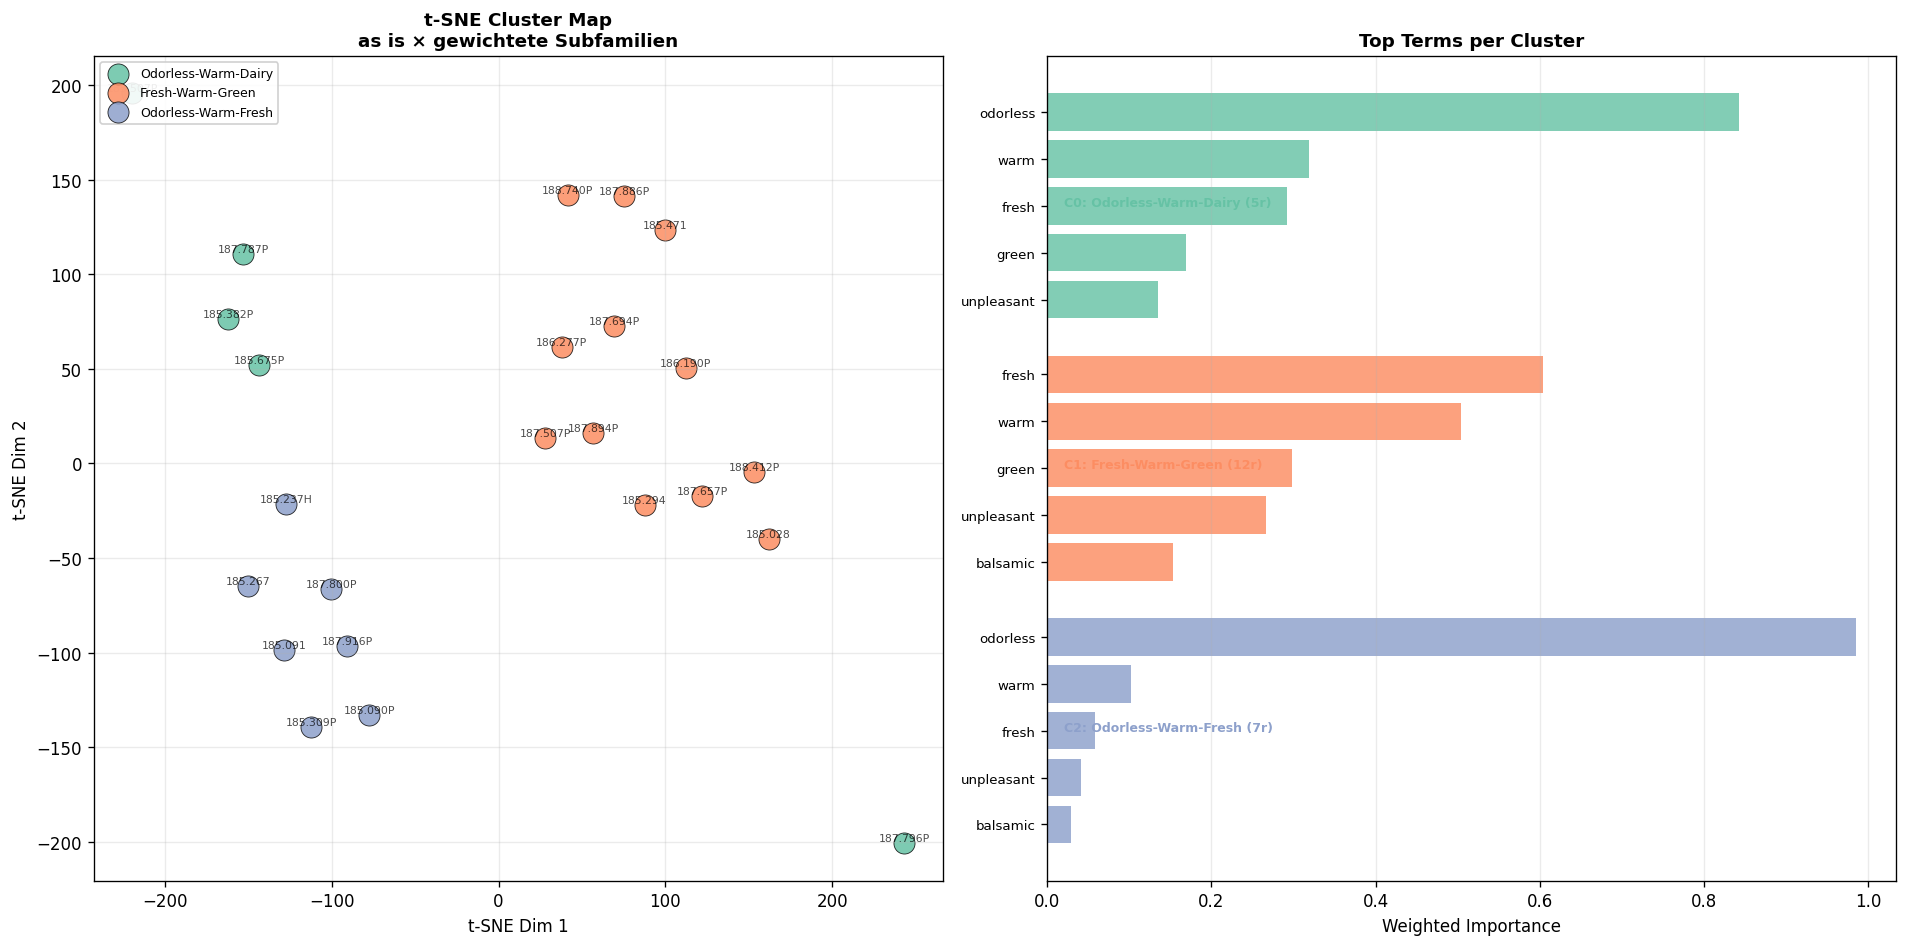

Saved → ../outputs/v8_radar_model1.png


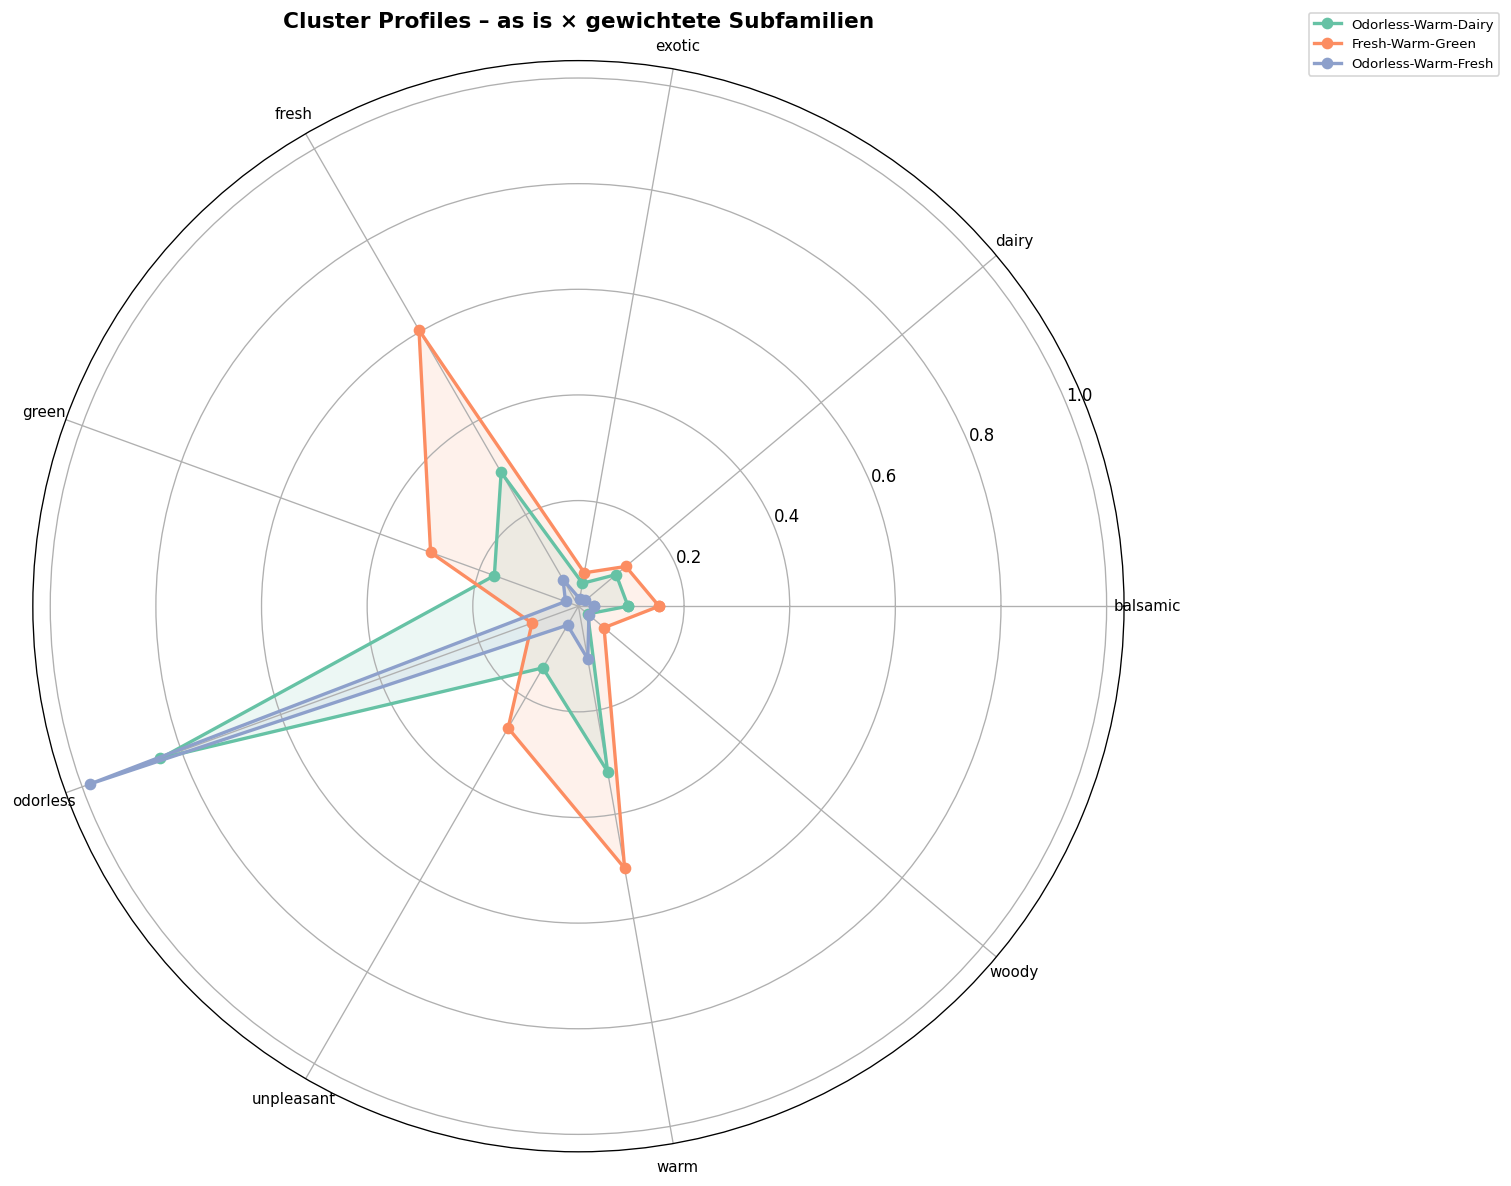


MODEL 2/4: as is × Grandfamilien
Vocabulary : 8 terms
Vector shape: (24, 8)
Non-zero dims per recipe: 5.7 (avg)

Silhouette scores by k:
  k= 3: 0.3307
  k= 4: 0.3040
  k= 5: 0.3333
  k= 6: 0.3476
  k= 7: 0.3319
  k= 8: 0.4033  ← selected
  k= 9: 0.3554
  k=10: 0.2962
  k=11: 0.2282
  k=12: 0.2022

Clusters (k=8):
  Cluster 0: 6 recipes  |  Odorless-Warm-Green
  Cluster 1: 3 recipes  |  Green-Dairy-Warm
  Cluster 2: 4 recipes  |  Odorless-Dairy
  Cluster 3: 2 recipes  |  Odorless-Warm
  Cluster 4: 3 recipes  |  Green-Warm-Unpleasant
  Cluster 5: 2 recipes  |  Fresh-Warm-Green
  Cluster 6: 2 recipes  |  Warm-Fresh-Unpleasant
  Cluster 7: 2 recipes  |  Warm-Unpleasant-Green

────────────────────────────────────────────────
CLUSTER 0: Odorless-Warm-Green  (6 recipes)
────────────────────────────────────────────────
  • 185.267
  • 185.091
  • 185.309P
  • 185.090P
  • 187.800P
  • 187.916P
  Top profile:
    odorless             ███████████████████████████████████████ (0.997)
    warm   

WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 9 centroids: please provide at least 351 training points
WARNING clustering 24 points to 10 centroids: please provide at least 390 training points
WARNING clustering 24 points to 11 centroids: please provide at least 429 training points
WARNING clustering 24 points to 12 centroids: please provide at least 468 training points


Saved → ../outputs/v8_cluster_model2.png


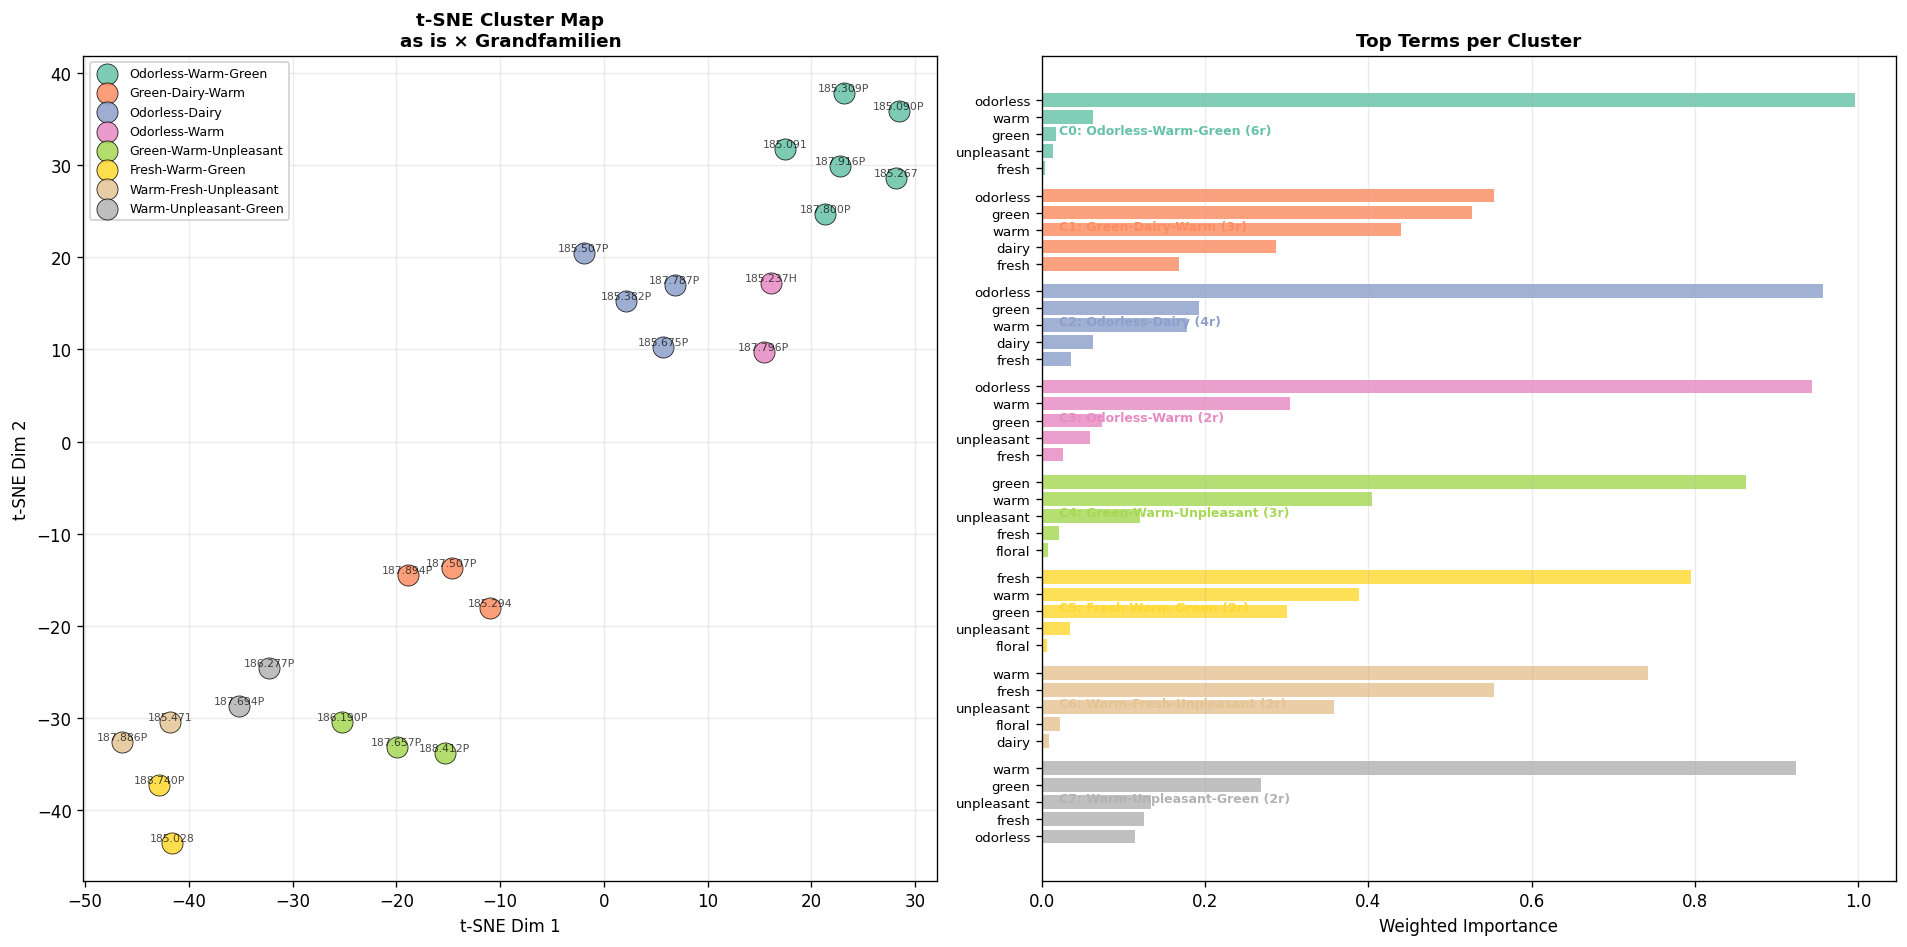

Saved → ../outputs/v8_radar_model2.png


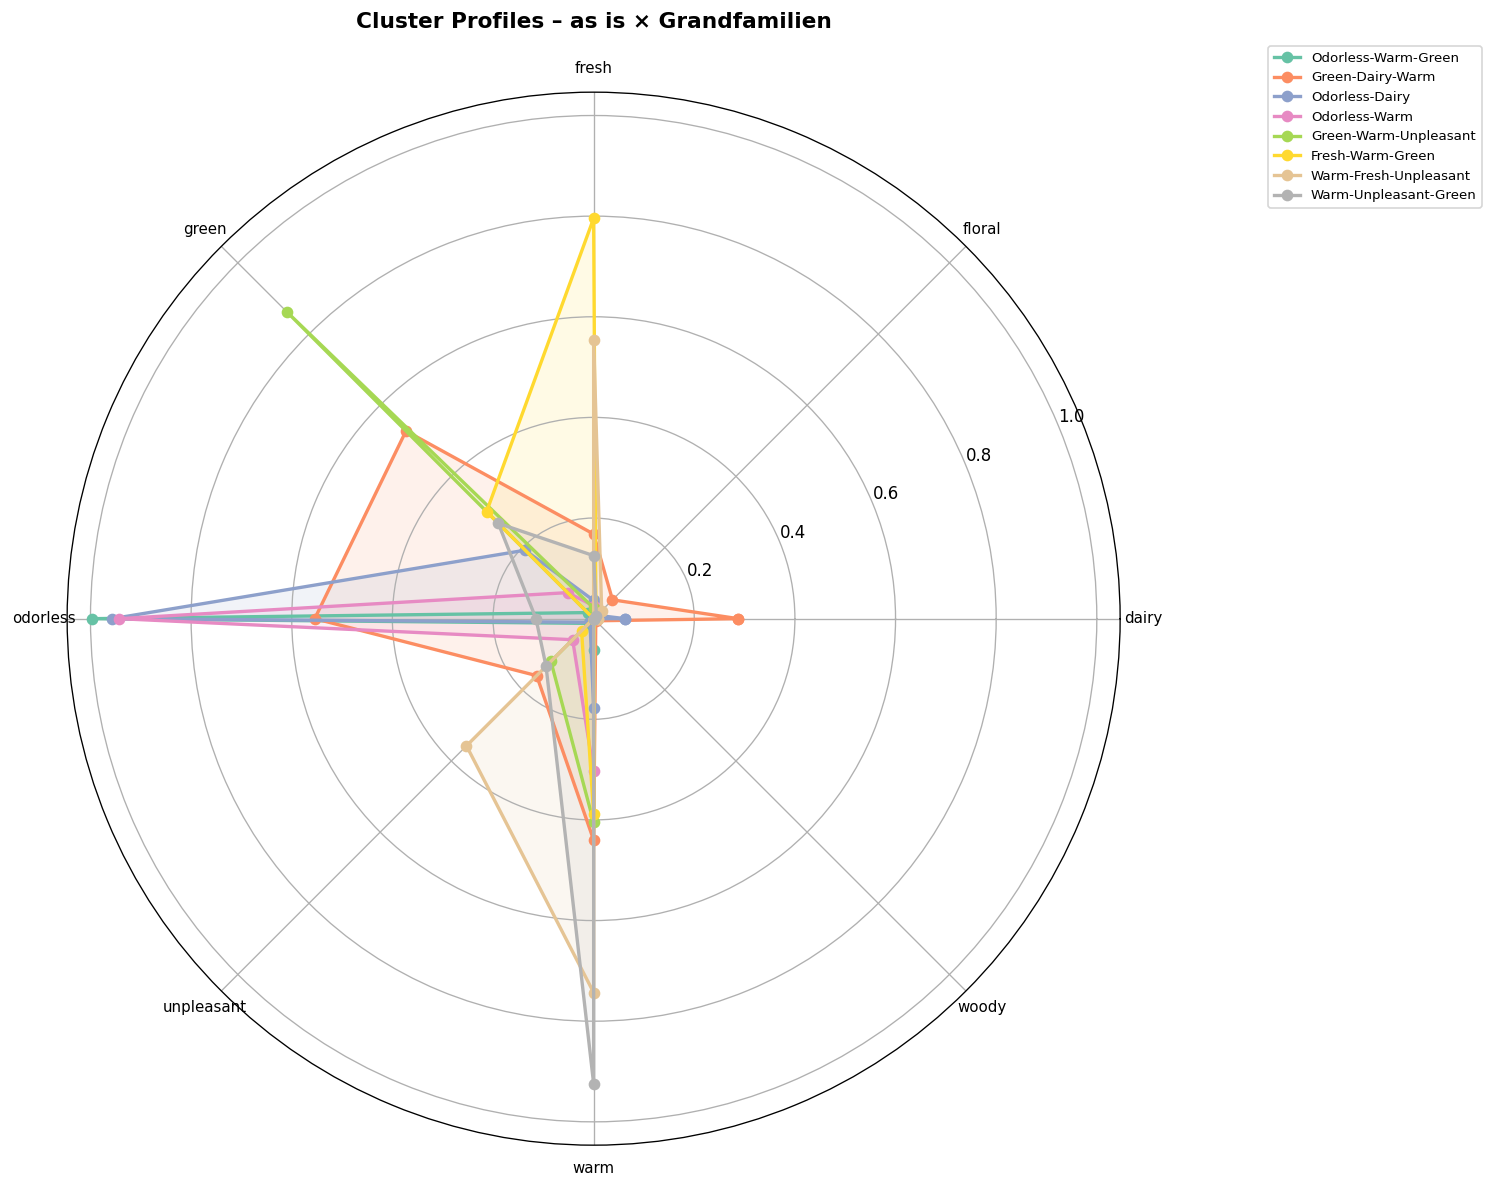


MODEL 3/4: as is/Threshold × gewichtete Subfamilien
Vocabulary : 10 terms
Vector shape: (24, 10)
Non-zero dims per recipe: 9.4 (avg)

Silhouette scores by k:
  k= 3: 0.2646
  k= 4: 0.2398
  k= 5: 0.2703
  k= 6: 0.2941  ← selected
  k= 7: 0.2320
  k= 8: 0.2420
  k= 9: 0.2298
  k=10: 0.2223
  k=11: 0.1401
  k=12: 0.1858

Clusters (k=6):
  Cluster 0: 2 recipes  |  Warm-Unpleasant-Balsamic
  Cluster 1: 7 recipes  |  Warm-Fresh-Floral
  Cluster 2: 2 recipes  |  Odorless-Warm-Green
  Cluster 3: 4 recipes  |  Odorless-Woody
  Cluster 4: 7 recipes  |  Green-Fresh-Balsamic
  Cluster 5: 2 recipes  |  Warm-Fresh-Balsamic

────────────────────────────────────────────────
CLUSTER 0: Warm-Unpleasant-Balsamic  (2 recipes)
────────────────────────────────────────────────
  • 187.796P
  • 185.267
  Top profile:
    warm                 ██████████████████████████ (0.655)
    fresh                ███████████████████ (0.484)
    unpleasant           ███████████ (0.289)
    balsamic             ██████████

WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 9 centroids: please provide at least 351 training points
WARNING clustering 24 points to 10 centroids: please provide at least 390 training points
WARNING clustering 24 points to 11 centroids: please provide at least 429 training points
WARNING clustering 24 points to 12 centroids: please provide at least 468 training points


Saved → ../outputs/v8_cluster_model3.png


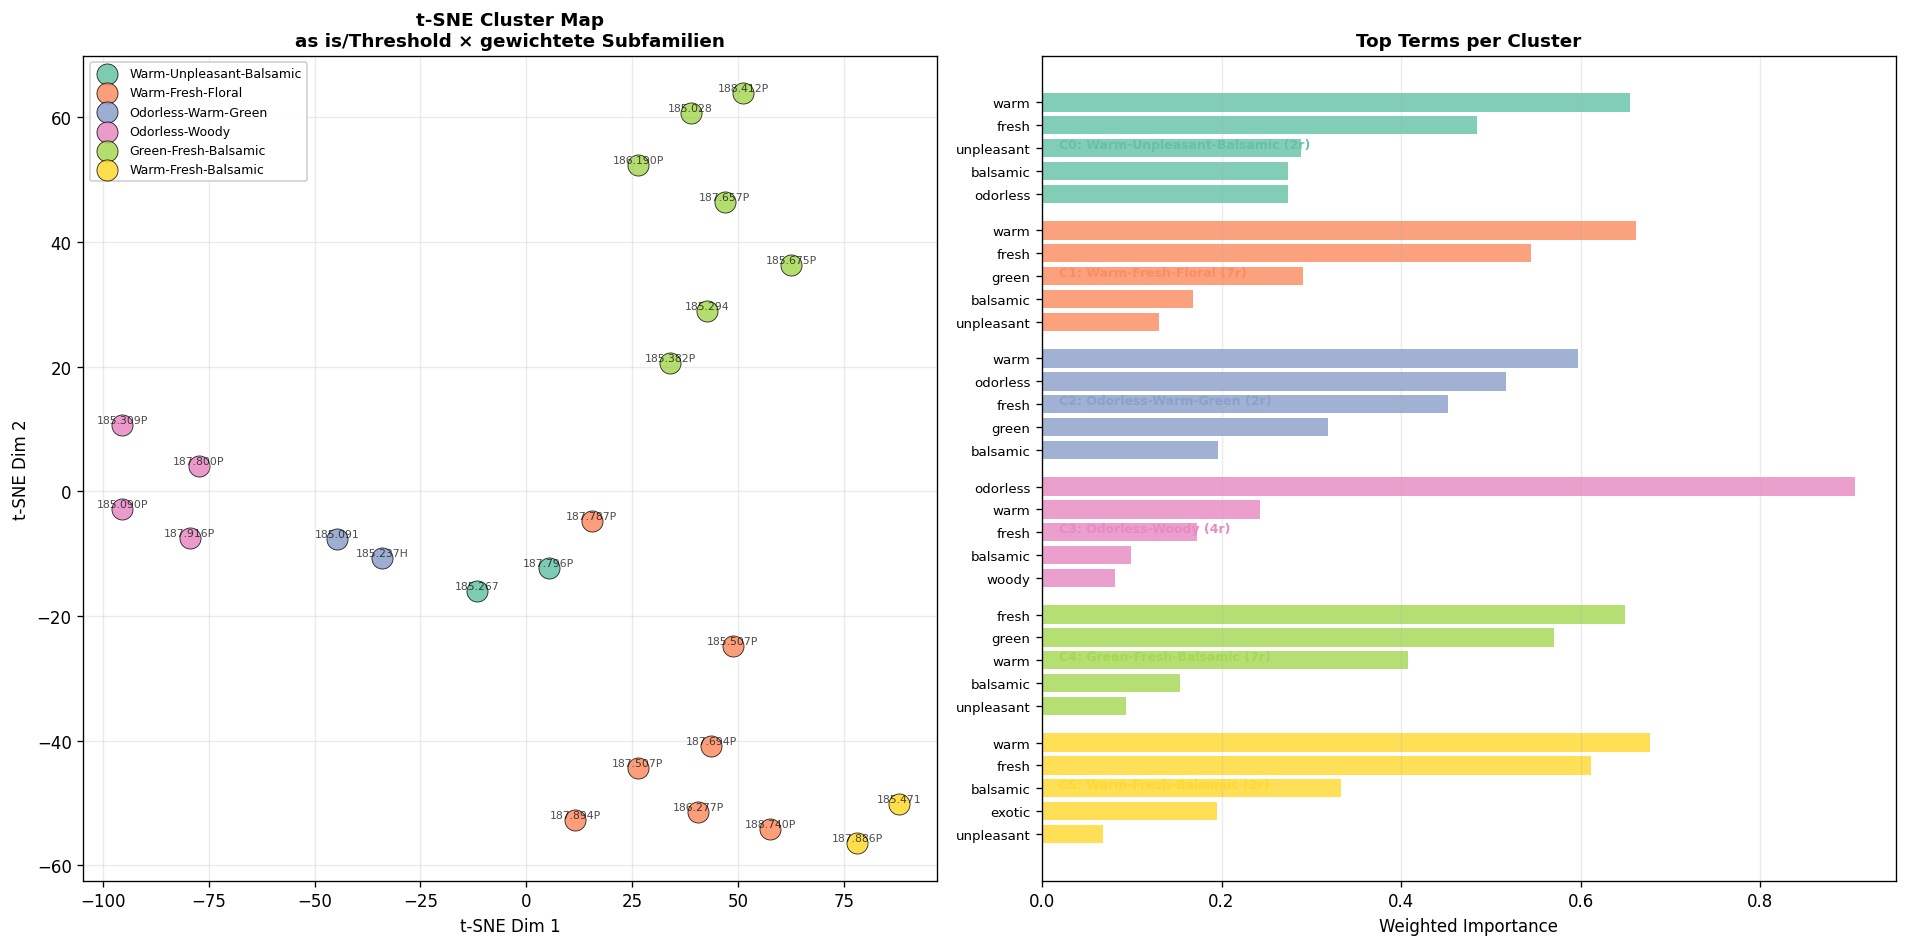

Saved → ../outputs/v8_radar_model3.png


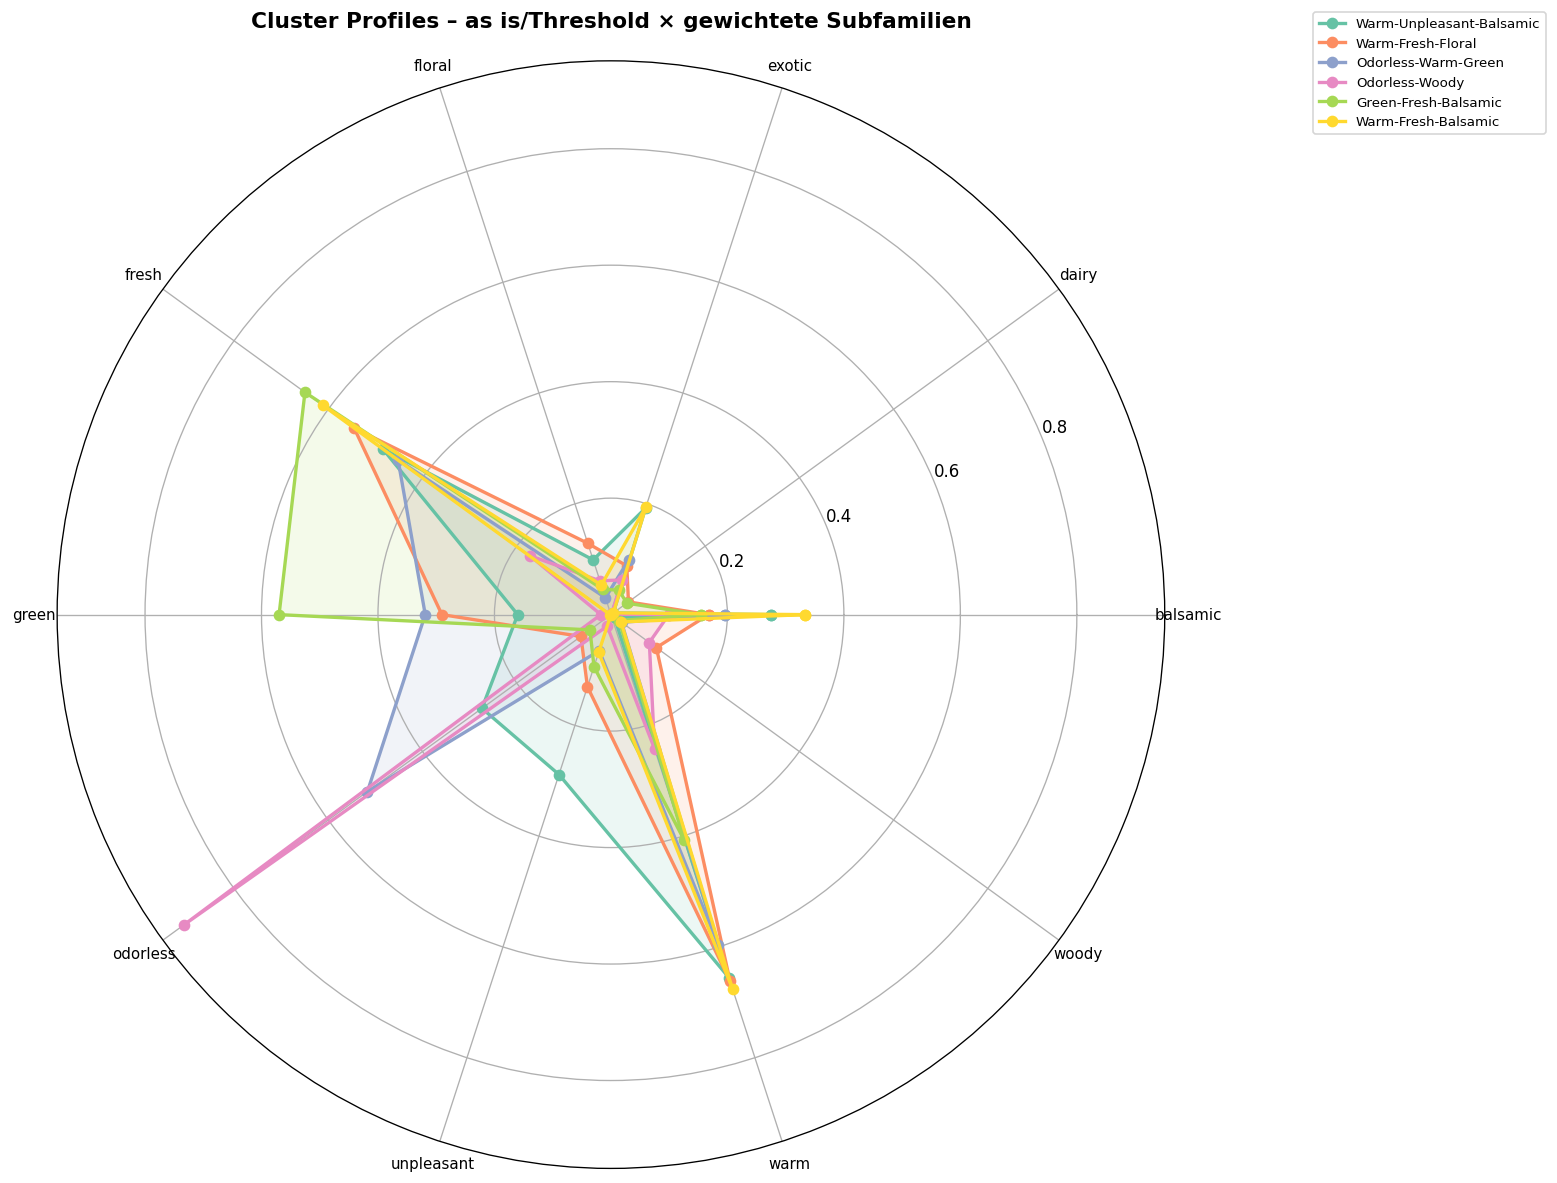


MODEL 4/4: as is/Threshold × Grandfamilien
Vocabulary : 8 terms
Vector shape: (24, 8)
Non-zero dims per recipe: 5.7 (avg)

Silhouette scores by k:
  k= 3: 0.3733
  k= 4: 0.3672
  k= 5: 0.3427
  k= 6: 0.3739
  k= 7: 0.4129  ← selected
  k= 8: 0.3912
  k= 9: 0.3488
  k=10: 0.3097
  k=11: 0.3562
  k=12: 0.3251

Clusters (k=7):
  Cluster 0: 2 recipes  |  Warm-Unpleasant-Odorless
  Cluster 1: 4 recipes  |  Warm-Green-Fresh
  Cluster 2: 5 recipes  |  Odorless-Green-Warm
  Cluster 3: 4 recipes  |  Odorless-Woody
  Cluster 4: 6 recipes  |  Green-Unpleasant-Dairy
  Cluster 5: 1 recipes  |  Floral-Warm
  Cluster 6: 2 recipes  |  Warm-Unpleasant-Floral

────────────────────────────────────────────────
CLUSTER 0: Warm-Unpleasant-Odorless  (2 recipes)
────────────────────────────────────────────────
  • 187.796P
  • 185.267
  Top profile:
    warm                 ███████████████████████████████ (0.793)
    odorless             █████████████████ (0.430)
    unpleasant           ████████████ (0.318)

WARNING clustering 24 points to 3 centroids: please provide at least 117 training points
WARNING clustering 24 points to 4 centroids: please provide at least 156 training points
WARNING clustering 24 points to 5 centroids: please provide at least 195 training points
WARNING clustering 24 points to 6 centroids: please provide at least 234 training points
WARNING clustering 24 points to 7 centroids: please provide at least 273 training points
WARNING clustering 24 points to 8 centroids: please provide at least 312 training points
WARNING clustering 24 points to 9 centroids: please provide at least 351 training points
WARNING clustering 24 points to 10 centroids: please provide at least 390 training points
WARNING clustering 24 points to 11 centroids: please provide at least 429 training points
WARNING clustering 24 points to 12 centroids: please provide at least 468 training points


Saved → ../outputs/v8_cluster_model4.png


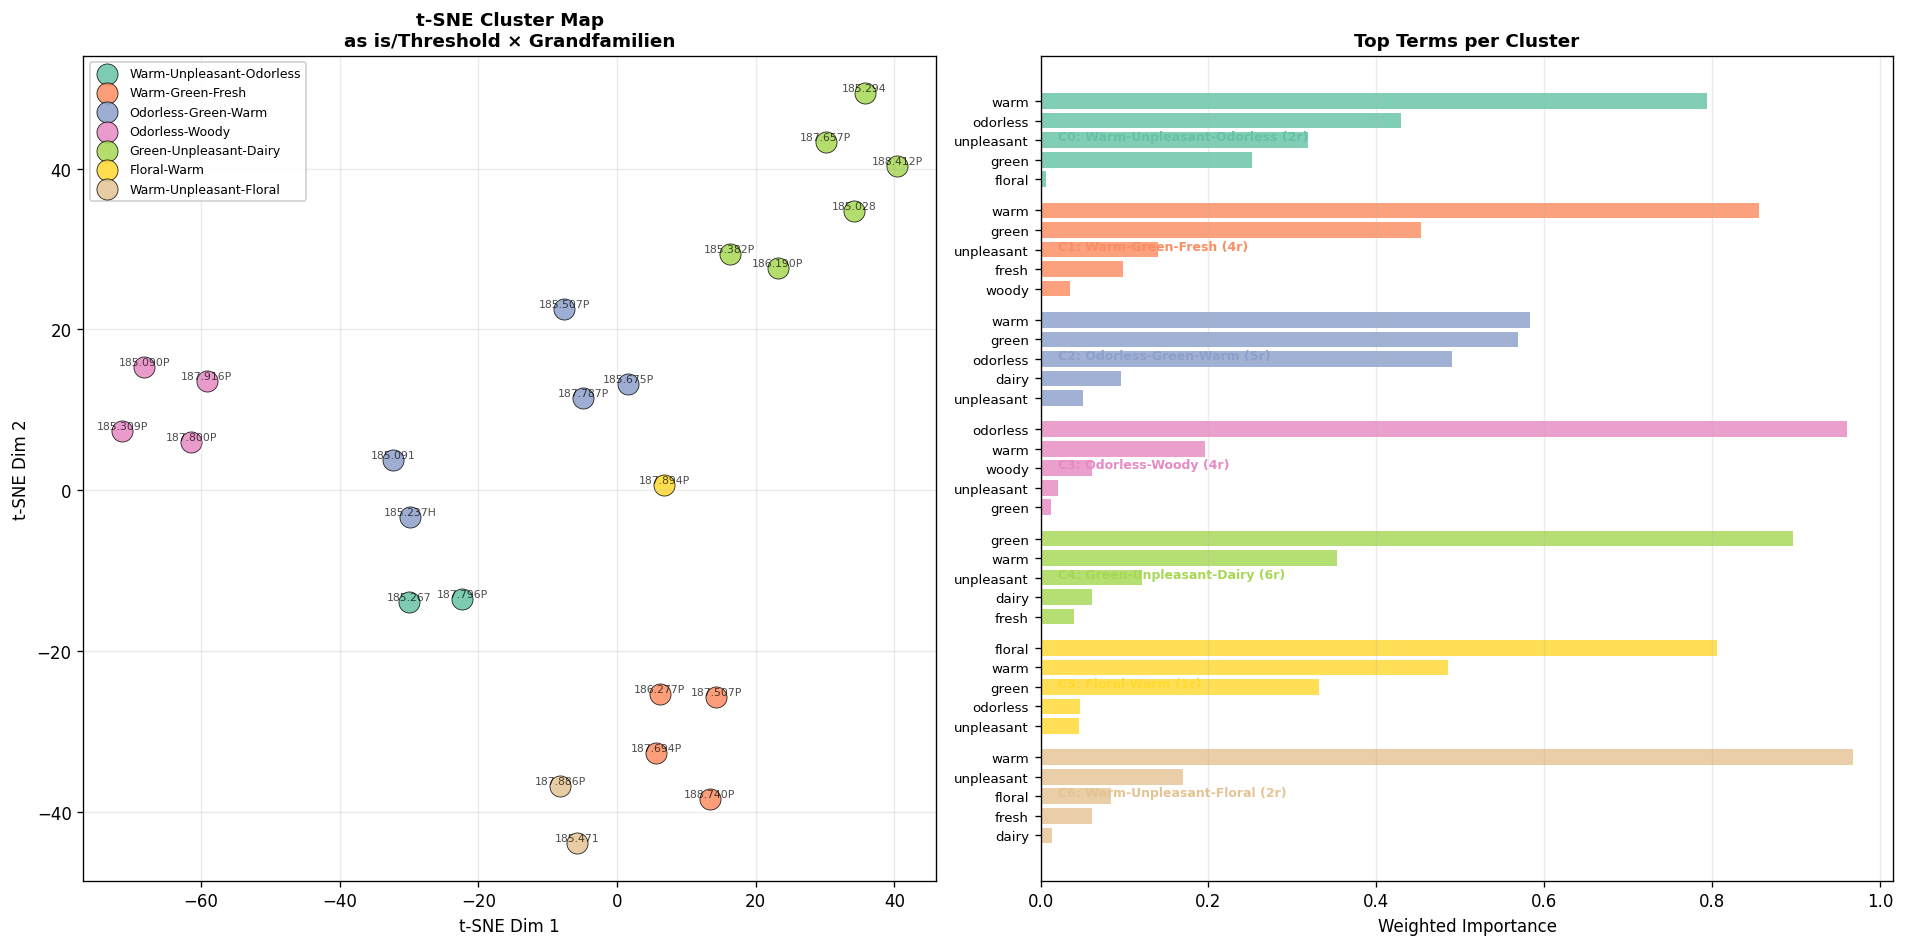

Saved → ../outputs/v8_radar_model4.png


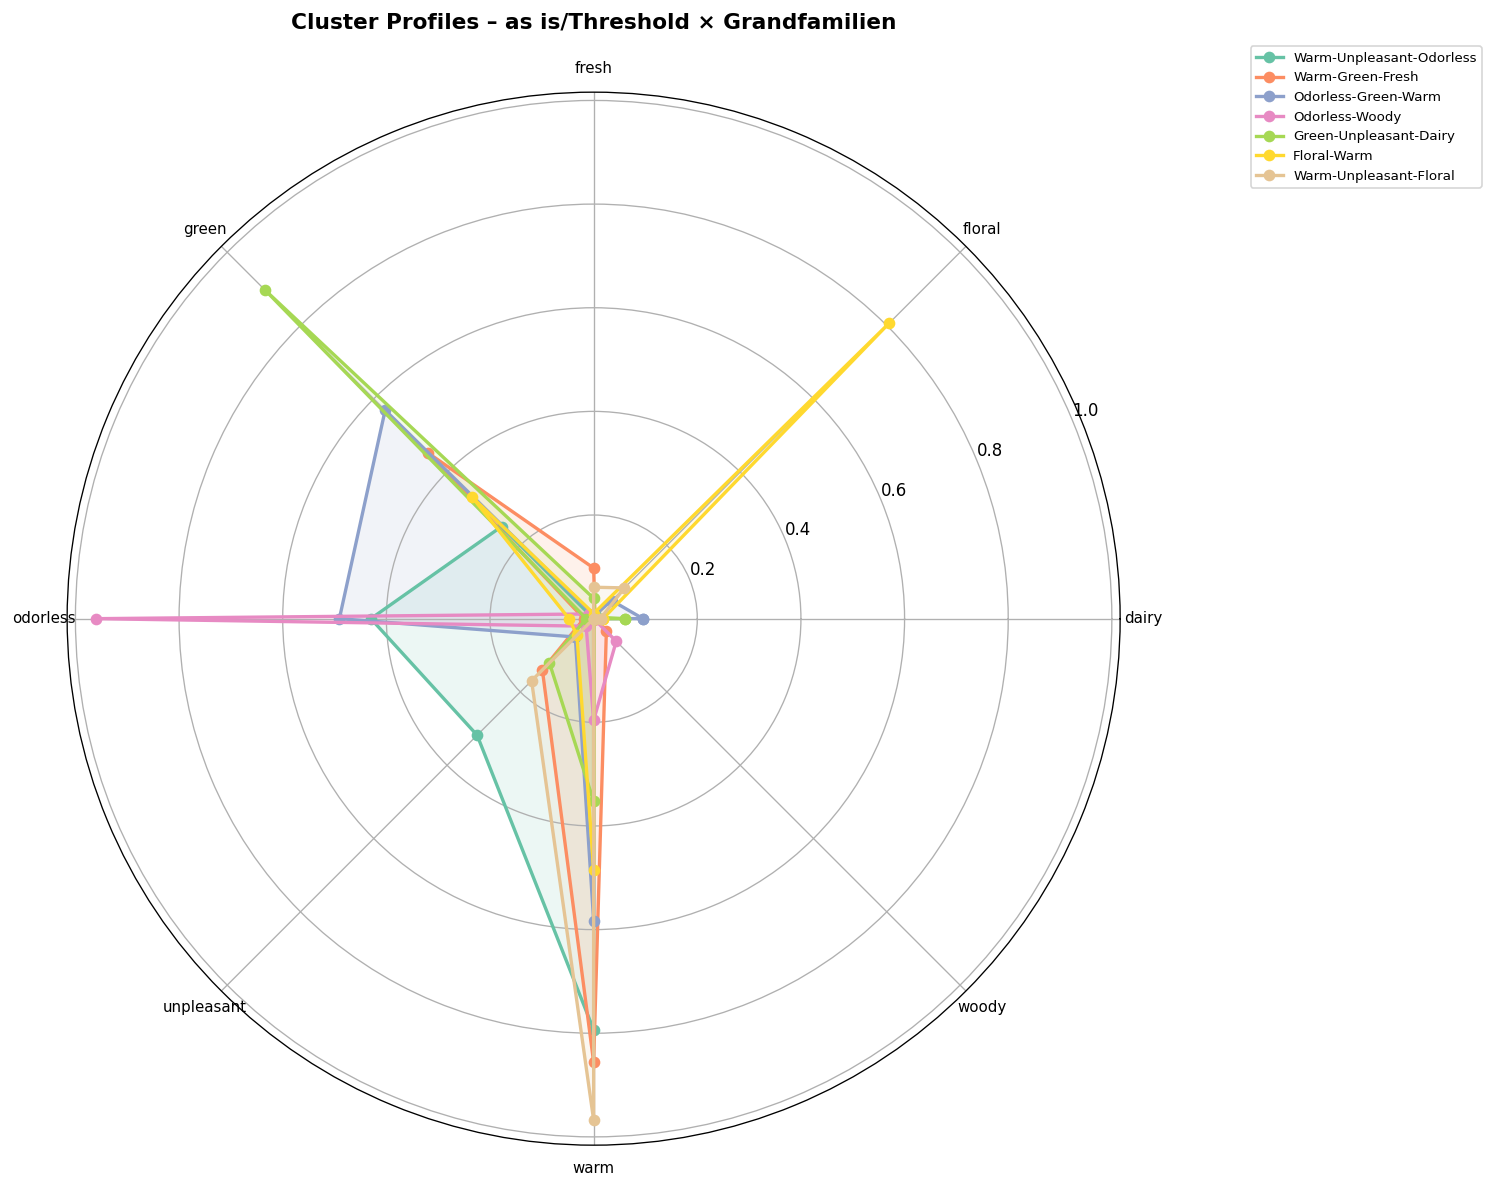



All 4 models completed!


In [17]:
results = {}

for i_cfg, cfg in enumerate(MODEL_CONFIGS, 1):
    name = cfg['name']
    print(f"\n{'='*65}")
    print(f"MODEL {i_cfg}/4: {name}")
    print('='*65)

    # Build vocabulary and recipe vectors
    vocab, recipe_vecs = build_recipe_vectors(
        df, recipes,
        feature_cols_weighted=cfg['feature_cols_weighted'],
        use_threshold=cfg['use_threshold'],
    )
    print(f"Vocabulary : {len(vocab)} terms")
    print(f"Vector shape: {recipe_vecs.shape}")
    print(f"Non-zero dims per recipe: {(recipe_vecs > 0).sum(axis=1).mean():.1f} (avg)")

    # FAISS clustering
    labels, best_k, best_score, centroids, scores = run_faiss_clustering(recipe_vecs)

    print(f"\nSilhouette scores by k:")
    for k_val, s_val in scores:
        marker = '  ← selected' if k_val == best_k else ''
        print(f"  k={k_val:2d}: {s_val:.4f}{marker}")

    # Names, details, summary
    cluster_names = generate_cluster_names(labels, recipe_vecs, vocab)
    details       = get_details(labels, cluster_names, recipe_vecs, vocab, recipes)

    print(f"\nClusters (k={best_k}):")
    for l in sorted(set(labels)):
        print(f"  Cluster {l}: {int((labels==l).sum())} recipes  |  {cluster_names[l]}")

    print_summary(details)

    # Visualizations
    safe = f"model{i_cfg}"
    coords = visualize_clusters(
        labels, cluster_names, details, recipe_vecs, vocab, recipes,
        title=name,
        save_path=f"{OUTPUT_DIR}/v8_cluster_{safe}.png",
    )
    visualize_radar(
        details, cluster_names,
        title=f"Cluster Profiles – {name}",
        recipe_vecs=recipe_vecs, vocab=vocab,
        save_path=f"{OUTPUT_DIR}/v8_radar_{safe}.png",
    )

    # Store results
    results[name] = {
        'vocab'        : vocab,
        'vectors'      : recipe_vecs,
        'labels'       : labels,
        'k'            : best_k,
        'score'        : best_score,
        'centroids'    : centroids,
        'cluster_names': cluster_names,
        'details'      : details,
        'tsne_coords'  : coords,
    }

print(f"\n\n{'='*65}")
print("All 4 models completed!")


---
## 6. Cross-Model Comparison


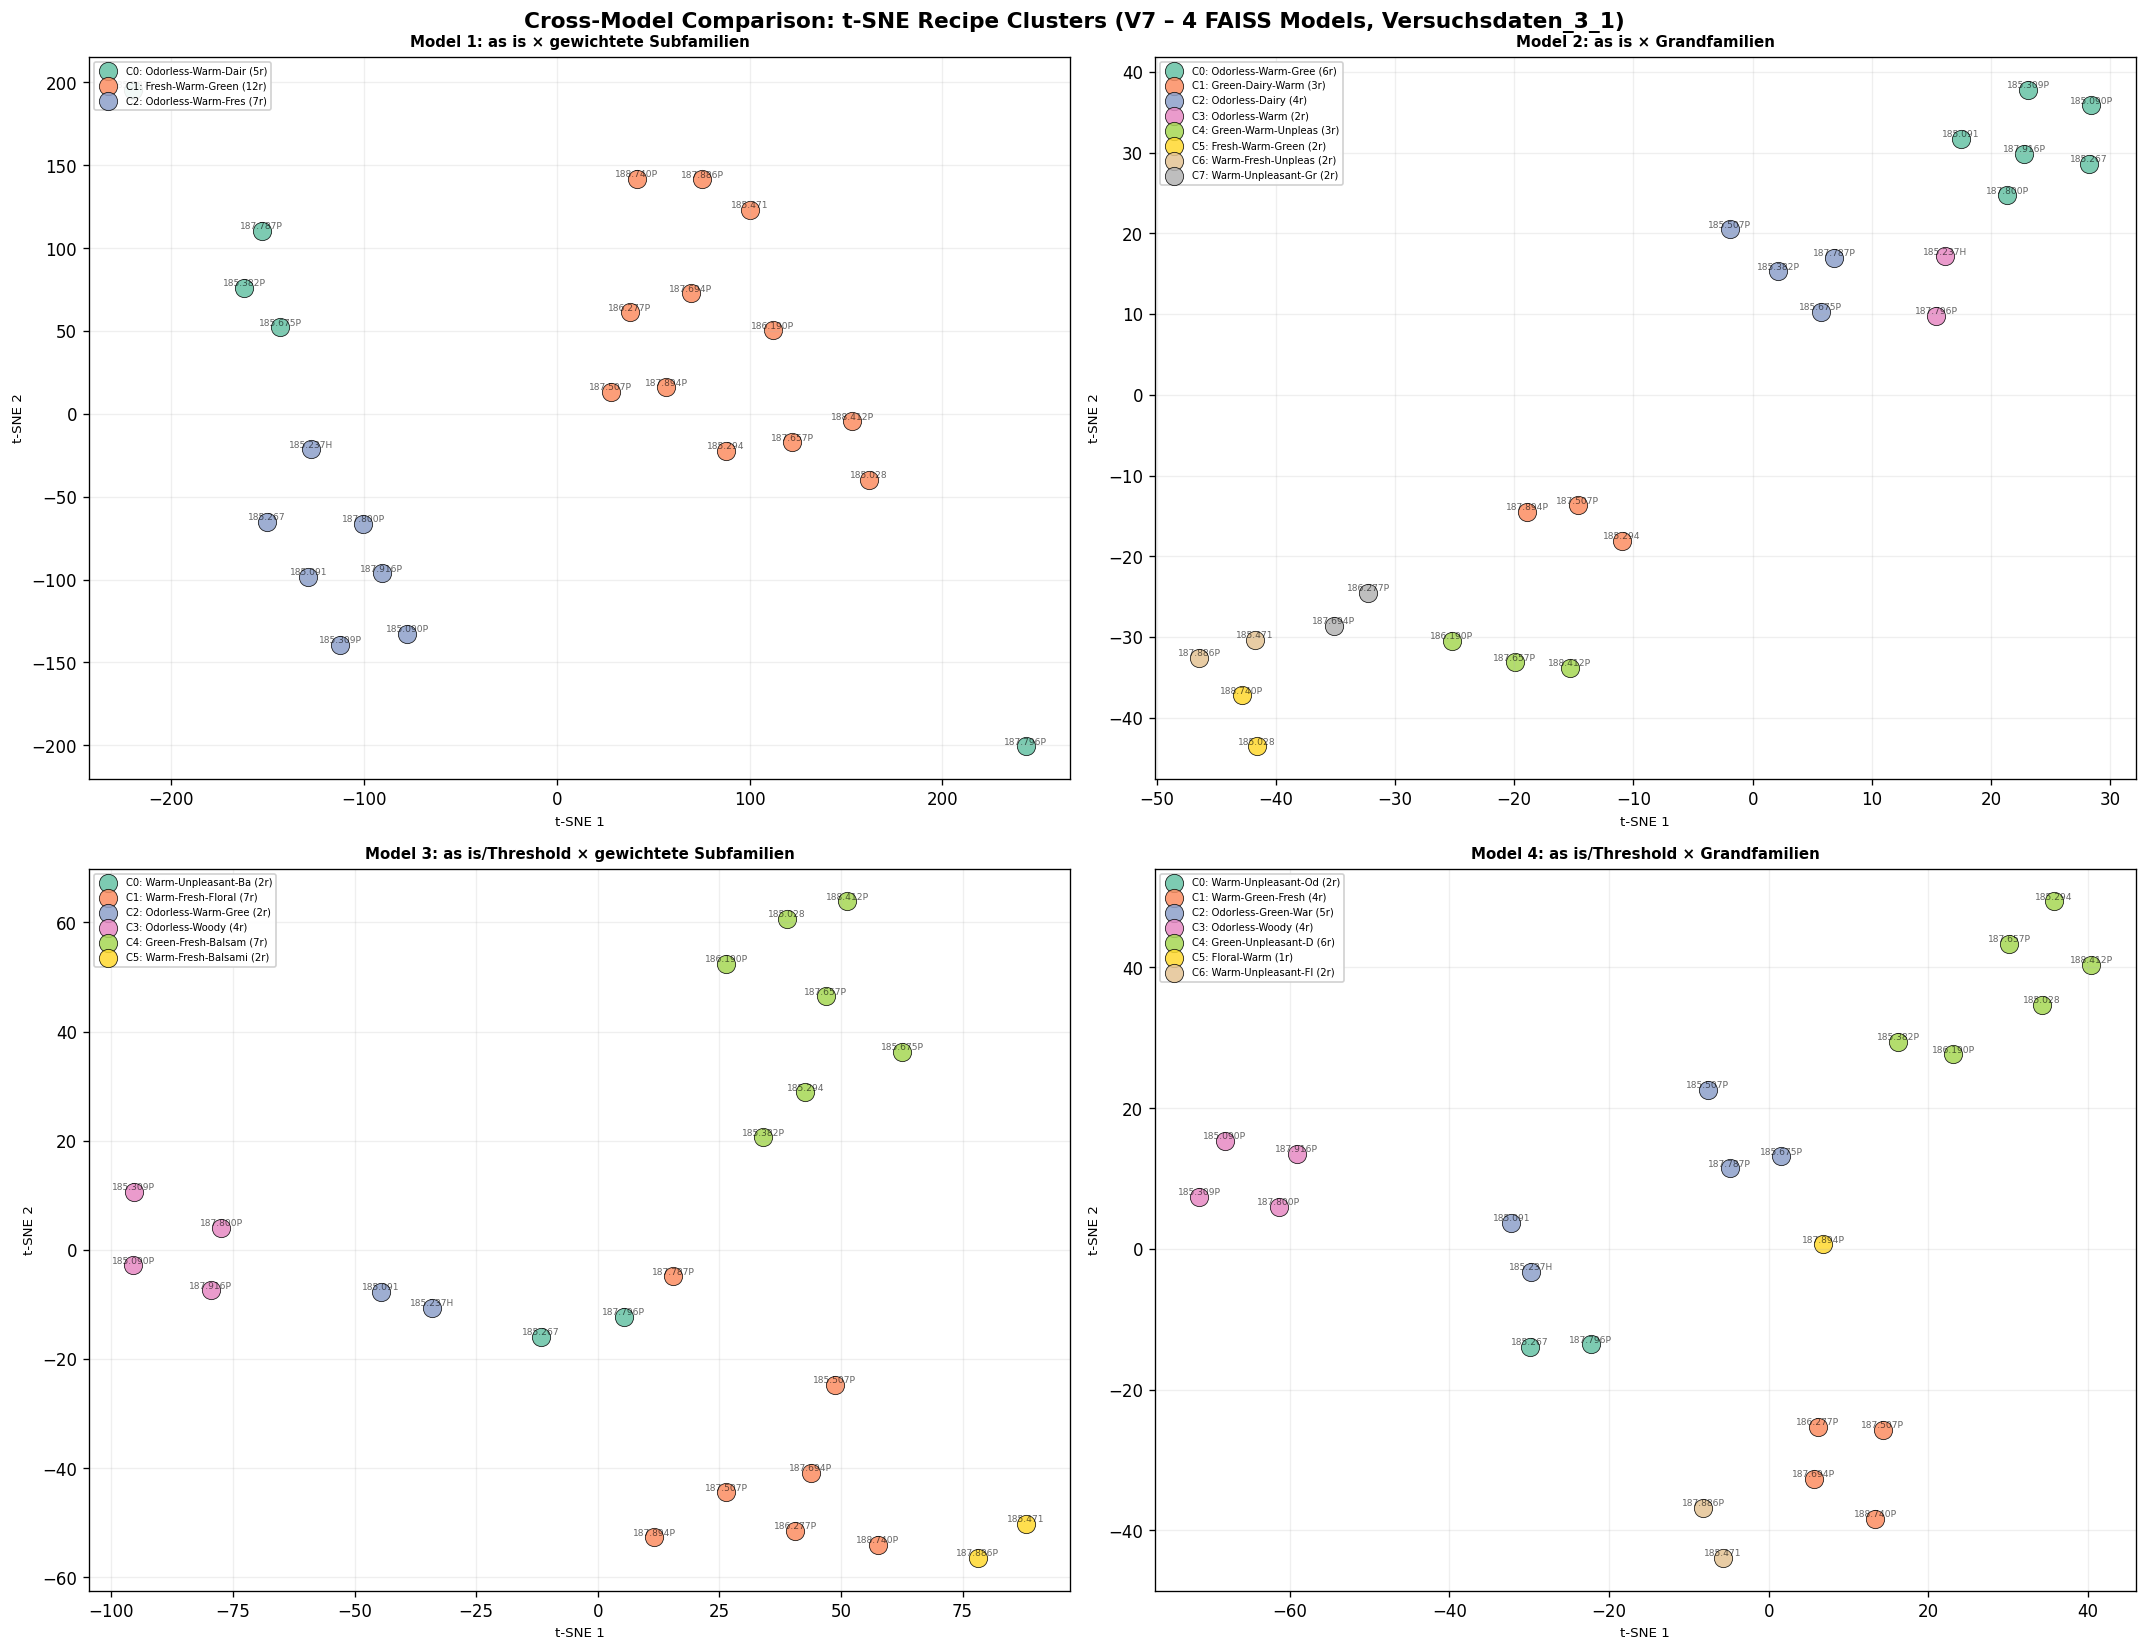

Saved → v7_comparison_tsne.png


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    ax     = axes[i]
    coords = res['tsne_coords']
    labels = res['labels']
    cnames = res['cluster_names']
    unique_labels = sorted(set(labels))
    colors = plt.cm.Set2(np.linspace(0, 1, max(len(unique_labels), 8)))

    for j, label in enumerate(unique_labels):
        mask = labels == label
        pts  = coords[mask]
        c    = 'gray' if label == -1 else colors[j % len(colors)]
        ax.scatter(pts[:, 0], pts[:, 1], c=[c], marker='o', s=120, alpha=0.85,
                   label=f"C{label}: {cnames.get(label,'')[:18]} ({mask.sum()}r)",
                   edgecolors='black', lw=0.5)
    for j, rec in enumerate(recipes):
        ax.annotate(rec[:10], (coords[j, 0], coords[j, 1]),
                    fontsize=5.5, alpha=0.6, ha='center', va='bottom')

    ax.set_title(f"Model {i+1}: {name}", fontsize=9, fontweight='bold')
    ax.legend(loc='upper left', fontsize=6, framealpha=0.9)
    ax.grid(True, alpha=0.2)
    ax.set_xlabel('t-SNE 1', fontsize=8)
    ax.set_ylabel('t-SNE 2', fontsize=8)

plt.suptitle('Cross-Model Comparison: t-SNE Recipe Clusters (V7 – 4 FAISS Models, Versuchsdaten_3_1)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/v8_comparison_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → v7_comparison_tsne.png")


In [19]:
print(f"\n{'='*90}")
print(f"{'Model':<48} {'k':>3} {'Silhouette':>11} {'Vocab':>6}  Cluster sizes")
print(f"{'='*90}")
for name, res in results.items():
    labels     = res['labels']
    k          = res['k']
    score      = res['score']
    vocab_size = len(res['vocab'])
    sizes = [f"C{l}:{int((labels==l).sum())}r" for l in sorted(set(labels))]
    print(f"{name:<48} {k:>3} {score:>11.4f} {vocab_size:>6}  {', '.join(sizes)}")



Model                                              k  Silhouette  Vocab  Cluster sizes
as is × gewichtete Subfamilien                     3      0.4433     10  C0:5r, C1:12r, C2:7r
as is × Grandfamilien                              8      0.4033      8  C0:6r, C1:3r, C2:4r, C3:2r, C4:3r, C5:2r, C6:2r, C7:2r
as is/Threshold × gewichtete Subfamilien           6      0.2941     10  C0:2r, C1:7r, C2:2r, C3:4r, C4:7r, C5:2r
as is/Threshold × Grandfamilien                    7      0.4129      8  C0:2r, C1:4r, C2:5r, C3:4r, C4:6r, C5:1r, C6:2r


---
## Summary

### V8 vs V7 – key differences

| Aspect | V7 | V8 |
|--------|----|----|
| **Data** | Versuchsdaten_3_1.csv | Versuchsdaten_3_1.csv (same) |
| **Columns** | Odour Type only | Odour Type only (same) |
| **Excluded terms** | None | `fruity` removed from vocabulary |
| **Models** | 4 FAISS models | 4 FAISS models (same) |

### EXCLUDE_TERMS mechanism (V8)
Three touch points, identical to V4/V6:
1. **Config cell** – defines `exclude_set = {'fruity'}`
2. **`build_vocabulary`** – skips any term in `exclude_set`
3. **`build_recipe_vectors`** – skips any term in `exclude_set` when accumulating weights

### Model design rationale

| Model | Captures |
|-------|----------|
| as is × gewichtete Subfamilien | Odour family diversity weighted by recipe share and column position |
| as is × Grandfamilien | Top-level odour family weighted purely by recipe share |
| as is/Threshold × gewichtete Subfamilien | Perceptual potency + family diversity (positional) |
| as is/Threshold × Grandfamilien | Perceptual potency + top-level family only |
